# 🏗️ Notebook 05: Hierarchical SOC Team with Microsoft Agent Framework

MAF gives us orchestration patterns beyond what ConnectedAgentTool offers — handoffs, group chats, concurrent execution, and more. In this notebook, we use those patterns to investigate a full ransomware attack chain.

In [10]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
import asyncio
from pathlib import Path
from IPython.display import display, Markdown
from soc_workshop.settings import get_settings
from soc_workshop.clients import configure_tracing
from soc_workshop.incident_schema import Alert, InvestigationRecord
import pandas as pd
import matplotlib.pyplot as plt

settings = get_settings()
configure_tracing(settings)

True

## Part 1: Handoff Pattern — Escalation Chain

Handoff passes the conversation from one agent to the next, like a SOC escalation: Tier-1 → Tier-2 → Incident Commander. Each analyst adds depth before passing control forward.

In [11]:
try:
    from agent_framework.azure import AzureOpenAIResponsesClient
    from agent_framework import Message
    from agent_framework.orchestrations import (
        HandoffBuilder,
        GroupChatBuilder,
        ConcurrentBuilder,
        SequentialBuilder,
    )
except ImportError as e:
    raise ImportError(
        "MAF imports failed. Install pre-release packages: agent-framework-core, agent-framework-azure-ai, and agent-framework-orchestrations."
    ) from e

from azure.identity.aio import DefaultAzureCredential as AsyncDefaultAzureCredential

credential = AsyncDefaultAzureCredential()
client = AzureOpenAIResponsesClient(
    project_endpoint=settings.project_endpoint,
    deployment_name=settings.model_deployment,
    credential=credential,
)

In [12]:
alerts_path = Path("../data/alerts.json")
alerts_raw = json.loads(alerts_path.read_text(encoding="utf-8"))
alerts_by_id = {a["alert_id"]: a for a in alerts_raw}

# Full ransomware chain: phishing → credential theft → Cobalt Strike → lateral movement → exfil → encryption
chain_ids = [
    "ALERT-2025-004",
    "ALERT-2025-002",
    "ALERT-2025-001",
    "ALERT-2025-005",
    "ALERT-2025-006",
    "ALERT-2025-003",
]
chain_alerts = [Alert.from_dict(dict(alerts_by_id[aid])) for aid in chain_ids]
chain_alert_dicts = [alerts_by_id[aid] for aid in chain_ids]

def format_alert(a):
    entities = ", ".join([f"{e['entity_type']}={e['value']}" for e in a.get('entities', [])])
    return f"[{a['timestamp']}] {a['alert_id']} ({a['severity']}) - {a['title']}\nDescription: {a['description']}\nEntities: {entities}"

incident_briefing = "\n\n".join(format_alert(a) for a in chain_alert_dicts)
alert_data_input = json.dumps(chain_alert_dicts, indent=2)

display(pd.DataFrame(chain_alert_dicts)[["alert_id", "title", "severity", "timestamp", "source"]])

,alert_id,title,severity,timestamp,source
0,ALERT-2025-004,Credential harvesting phishing email detected,Medium,2025-03-07T09:45:00Z,Microsoft Defender for Office 365
1,ALERT-2025-002,Anomalous sign-in from TOR exit node,High,2025-03-07T03:18:45Z,Microsoft Entra ID Protection
2,ALERT-2025-001,Suspicious PowerShell execution with encoded c...,High,2025-03-07T14:32:11Z,Microsoft Defender for Endpoint
3,ALERT-2025-005,Lateral movement via PsExec to domain controller,Critical,2025-03-07T14:55:02Z,Microsoft Defender for Identity
4,ALERT-2025-006,Data exfiltration to cloud storage service,High,2025-03-07T14:48:00Z,Microsoft Defender for Cloud Apps
5,ALERT-2025-003,Mass file encryption detected on network share,Critical,2025-03-07T15:01:33Z,Microsoft Defender for Endpoint


In [13]:
tier1 = client.as_agent(
    name="soc-05-tier1-analyst",
    model=settings.model_deployment,
    instructions="You are a Tier-1 SOC Analyst. Perform initial triage: classify the alert severity, identify key entities, and determine if escalation is needed. If the alert is High or Critical severity, hand off to Tier-2. Include your initial assessment."
)
tier2 = client.as_agent(
    name="soc-05-tier2-analyst",
    model=settings.model_deployment,
    instructions="You are a Tier-2 SOC Analyst. Perform deep investigation: analyze the attack chain, correlate related alerts, identify the full scope of compromise. If this is a confirmed incident requiring executive notification, hand off to the Incident Commander."
)
incident_commander = client.as_agent(
    name="soc-05-incident-commander",
    model=settings.model_deployment,
    instructions="You are the Incident Commander. Produce the final incident report: Executive Summary, Impact Assessment, Timeline, Containment Actions Taken, Recommended Next Steps. This report goes to CISO and legal."
)

workflow = (
    HandoffBuilder(
        participants=[tier1, tier2, incident_commander],
        termination_condition=lambda conversation: len(conversation) >= 6,
    )
    .with_start_agent(tier1)
    .build()
)
handoff_start = asyncio.get_running_loop().time()
handoff_events = await workflow.run(incident_briefing)
handoff_seconds = round(asyncio.get_running_loop().time() - handoff_start, 2)
display(Markdown(f"✅ Handoff workflow finished in **{handoff_seconds}s**"))


✅ Handoff workflow finished in **89.01s**

In [14]:
def extract_messages(events_result):
    """Extract Message objects from workflow run result."""
    outputs = events_result.get_outputs()
    if not outputs:
        return []
    messages = []
    for output in outputs:
        if isinstance(output, list):
            # Orchestration yield_output(full_conversation) -> list[Message]
            for item in output:
                if hasattr(item, "role") and hasattr(item, "text"):
                    messages.append(item)
        elif hasattr(output, "messages"):
            # AgentResponse from AgentExecutor -> unwrap .messages
            for msg in output.messages:
                messages.append(msg)
        elif hasattr(output, "text"):
            messages.append(output)
    return messages


handoff_messages = extract_messages(handoff_events)
rows = []
for i, msg in enumerate(handoff_messages, start=1):
    if msg.role == "assistant" and msg.text:
        speaker = msg.author_name or f"step-{i}"
        rows.append({"order": i, "agent": speaker, "contribution": str(msg.text)[:1200]})

display(pd.DataFrame(rows) if rows else pd.DataFrame([{"agent": "n/a", "contribution": "No output captured"}]))


,order,agent,contribution
0,1,soc-05-tier1-analyst,### Initial Triage & Assessment\n\n#### Summar...
1,3,soc-05-tier2-analyst,## Deep Attack Chain Analysis & Correlation\n\...
2,5,soc-05-incident-commander,# Final Incident Report: Contoso Credential Co...


## Part 2: GroupChat Pattern — SOC War Room

GroupChat lets multiple specialists discuss the incident together, building on each other's analysis. This simulates a live SOC war room where hypotheses are refined round by round.

In [15]:
threat_hunter = client.as_agent(
    name="soc-05-threat-hunter",
    model=settings.model_deployment,
    instructions="You are a Threat Hunter. Focus on attacker TTPs, C2, lateral movement, and likely persistence mechanisms."
)
iam_analyst = client.as_agent(
    name="soc-05-iam-analyst",
    model=settings.model_deployment,
    instructions="You are an IAM Analyst. Investigate account compromise, privilege escalation, MFA gaps, and identity abuse."
)
endpoint_analyst = client.as_agent(
    name="soc-05-endpoint-analyst",
    model=settings.model_deployment,
    instructions="You are an Endpoint Analyst. Focus on host timeline, malware execution artifacts, and containment actions per endpoint."
)

In [16]:
orchestrator = client.as_agent(
    name="soc-05-groupchat-orchestrator",
    model=settings.model_deployment,
    instructions="You are the SOC War Room orchestrator. Select which specialist should speak next based on the investigation so far. Rotate between threat-hunter, iam-analyst, and endpoint-analyst to build a complete picture.",
)

war_room = (
    GroupChatBuilder(
        participants=[threat_hunter, iam_analyst, endpoint_analyst],
        orchestrator_agent=orchestrator,
        termination_condition=lambda messages: sum(1 for msg in messages if msg.role == "assistant") >= 6,
    )
    .build()
)
group_start = asyncio.get_running_loop().time()
groupchat_events = await war_room.run(incident_briefing)
groupchat_seconds = round(asyncio.get_running_loop().time() - group_start, 2)
display(Markdown(f"✅ GroupChat finished in **{groupchat_seconds}s**"))


✅ GroupChat finished in **48.46s**

In [17]:
group_messages = extract_messages(groupchat_events)
transcript_rows = []
for i, msg in enumerate(group_messages, start=1):
    if msg.role == "assistant" and msg.text:
        speaker = msg.author_name or f"round-{i}"
        transcript_rows.append({"order": i, "agent": speaker, "message": str(msg.text)[:1200]})

display(pd.DataFrame(transcript_rows) if transcript_rows else pd.DataFrame([{"agent": "n/a", "message": "No output captured"}]))


,order,agent,message
0,2,soc-05-iam-analyst,**Investigation Summary:**\n\nYou have a clear...
1,3,soc-05-endpoint-analyst,### Host Timeline and Endpoint Analysis\n\n###...
2,4,soc-05-threat-hunter,"### Threat Hunter Report: Attacker TTPs, C2, L..."
3,5,soc-05-groupchat-orchestrator,The attack lifecycle and impact are understood...


## Part 3: Concurrent Pattern — Parallel Investigation

Run multiple analysts simultaneously for faster triage. This pattern is ideal when tasks are independent and speed matters more than back-and-forth debate.

In [18]:
parallel = (
    ConcurrentBuilder(participants=[threat_hunter, iam_analyst, endpoint_analyst])
    .build()
)
concurrent_start = asyncio.get_running_loop().time()
concurrent_events = await parallel.run(alert_data_input)
concurrent_seconds = round(asyncio.get_running_loop().time() - concurrent_start, 2)

concurrent_outputs = concurrent_events.get_outputs()
parallel_rows = []
for i, output in enumerate(concurrent_outputs, start=1):
    if isinstance(output, list):
        # list[Message] from orchestration
        assistant_msgs = [m for m in output if hasattr(m, "role") and m.role == "assistant" and m.text]
        if assistant_msgs:
            last_msg = assistant_msgs[-1]
            speaker = last_msg.author_name or f"analyst-{i}"
            parallel_rows.append({"agent": speaker, "parallel_result": str(last_msg.text)[:1200]})
    elif hasattr(output, "messages"):
        # AgentResponse — extract assistant messages
        assistant_msgs = [m for m in output.messages if m.role == "assistant" and m.text]
        if assistant_msgs:
            last_msg = assistant_msgs[-1]
            speaker = last_msg.author_name or f"analyst-{i}"
            parallel_rows.append({"agent": speaker, "parallel_result": str(last_msg.text)[:1200]})

display(pd.DataFrame(parallel_rows) if parallel_rows else pd.DataFrame([{"agent": "n/a", "parallel_result": "No output captured"}]))

timing_df = pd.DataFrame([
    {"pattern": "Handoff", "seconds": handoff_seconds},
    {"pattern": "GroupChat", "seconds": groupchat_seconds},
    {"pattern": "Concurrent", "seconds": concurrent_seconds},
])
display(timing_df.sort_values("seconds"))


,agent,parallel_result
0,soc-05-endpoint-analyst,### Timeline & Analysis: Host WKS-FIN-PC04 – M...


,pattern,seconds
2,Concurrent,40.32
1,GroupChat,48.46
0,Handoff,89.01


## Comparing Orchestration Patterns

In [19]:
comparison_df = pd.DataFrame([
    {
        "Name": "Handoff",
        "Use Case": "Escalation chain",
        "Execution": "Sequential ownership transfer",
        "SOC Application": "Tier-1 to Tier-2 to Incident Commander",
        "Pros": "Clear accountability, structured escalation",
        "Cons": "Slower if early stages bottleneck",
    },
    {
        "Name": "GroupChat",
        "Use Case": "Collaborative analysis",
        "Execution": "Multi-round shared discussion",
        "SOC Application": "War room for complex incidents",
        "Pros": "Cross-domain reasoning, richer context",
        "Cons": "Higher token/time cost",
    },
    {
        "Name": "Concurrent",
        "Use Case": "Fast parallel triage",
        "Execution": "Independent simultaneous runs",
        "SOC Application": "Split identity/endpoint/threat tracks",
        "Pros": "Fastest turnaround",
        "Cons": "Needs later synthesis step",
    },
])
display(comparison_df)

,Name,Use Case,Execution,SOC Application,Pros,Cons
0,Handoff,Escalation chain,Sequential ownership transfer,Tier-1 to Tier-2 to Incident Commander,"Clear accountability, structured escalation",Slower if early stages bottleneck
1,GroupChat,Collaborative analysis,Multi-round shared discussion,War room for complex incidents,"Cross-domain reasoning, richer context",Higher token/time cost
2,Concurrent,Fast parallel triage,Independent simultaneous runs,Split identity/endpoint/threat tracks,Fastest turnaround,Needs later synthesis step


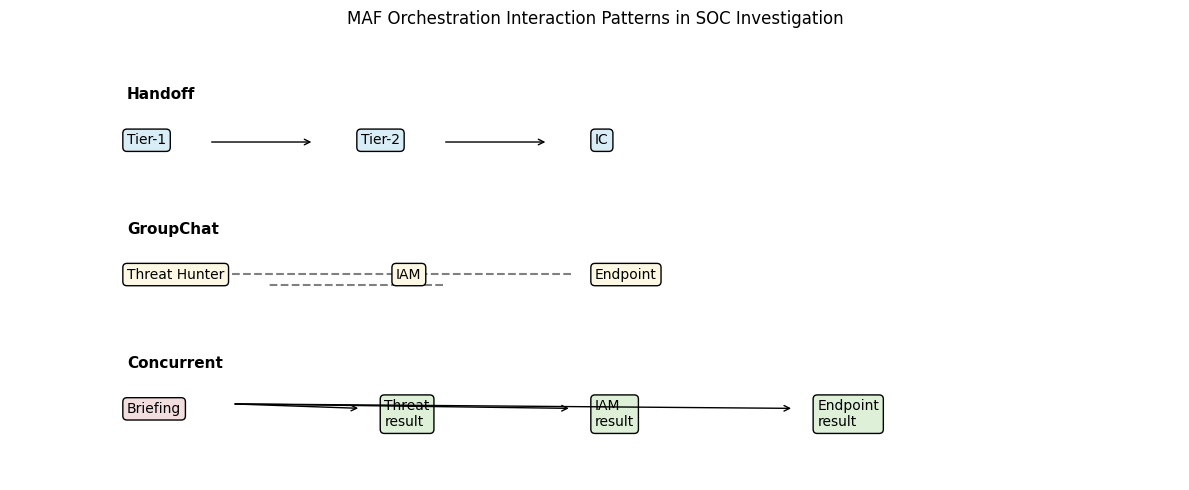

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Handoff lane
ax.text(1, 8.5, "Handoff", fontsize=11, fontweight="bold")
ax.annotate("Tier-1", (1.0, 7.5), bbox=dict(boxstyle="round", fc="#d9edf7"))
ax.annotate("Tier-2", (3.0, 7.5), bbox=dict(boxstyle="round", fc="#d9edf7"))
ax.annotate("IC", (5.0, 7.5), bbox=dict(boxstyle="round", fc="#d9edf7"))
ax.annotate("", xy=(2.6, 7.55), xytext=(1.7, 7.55), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(4.6, 7.55), xytext=(3.7, 7.55), arrowprops=dict(arrowstyle="->"))

# Group chat lane
ax.text(1, 5.5, "GroupChat", fontsize=11, fontweight="bold")
ax.annotate("Threat Hunter", (1.0, 4.5), bbox=dict(boxstyle="round", fc="#fcf8e3"))
ax.annotate("IAM", (3.3, 4.5), bbox=dict(boxstyle="round", fc="#fcf8e3"))
ax.annotate("Endpoint", (5.0, 4.5), bbox=dict(boxstyle="round", fc="#fcf8e3"))
ax.plot([1.8, 3.1, 4.8], [4.6, 4.6, 4.6], linestyle="--", color="gray")
ax.plot([3.7, 2.2], [4.35, 4.35], linestyle="--", color="gray")

# Concurrent lane
ax.text(1, 2.5, "Concurrent", fontsize=11, fontweight="bold")
ax.annotate("Briefing", (1.0, 1.5), bbox=dict(boxstyle="round", fc="#f2dede"))
ax.annotate("Threat\nresult", (3.2, 1.2), bbox=dict(boxstyle="round", fc="#dff0d8"))
ax.annotate("IAM\nresult", (5.0, 1.2), bbox=dict(boxstyle="round", fc="#dff0d8"))
ax.annotate("Endpoint\nresult", (6.9, 1.2), bbox=dict(boxstyle="round", fc="#dff0d8"))
ax.annotate("", xy=(3.0, 1.6), xytext=(1.9, 1.7), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(4.8, 1.6), xytext=(1.9, 1.7), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(6.7, 1.6), xytext=(1.9, 1.7), arrowprops=dict(arrowstyle="->"))

plt.title("MAF Orchestration Interaction Patterns in SOC Investigation")
plt.tight_layout()
plt.show()

In [21]:
def _result_to_text(events_result):
    """Convert workflow result to text for serialization."""
    if events_result is None:
        return ""
    try:
        outputs = events_result.get_outputs()
        parts = []
        for output in outputs:
            if isinstance(output, list):
                for msg in output:
                    if hasattr(msg, "role") and hasattr(msg, "text") and msg.text:
                        speaker = getattr(msg, "author_name", None) or msg.role
                        parts.append(f"[{speaker}]: {msg.text}")
            elif hasattr(output, "messages"):
                # AgentResponse
                for msg in output.messages:
                    if msg.text:
                        speaker = getattr(msg, "author_name", None) or msg.role
                        parts.append(f"[{speaker}]: {msg.text}")
            elif hasattr(output, "text") and output.text:
                parts.append(output.text)
        return "\n\n".join(parts) if parts else str(events_result)
    except Exception:
        return str(events_result)


all_entities = []
seen = set()
for a in chain_alert_dicts:
    for e in a.get("entities", []):
        key = (e.get("entity_type"), e.get("value"))
        if key not in seen:
            seen.add(key)
            all_entities.append(e)

record = InvestigationRecord(
    incident_id="INC-2025-RANSOMWARE-05",
    title="Ransomware Attack Chain - MAF Hierarchical SOC Investigation",
    alerts=chain_alerts,
    entities=all_entities,
    hypothesis="Credential phishing led to account abuse, C2, lateral movement, exfiltration, and ransomware impact.",
    verdict="True Positive",
    confidence=0.94,
    recommended_actions=[
        "Isolate WKS-FIN-PC04 and disable compromised accounts",
        "Reset credentials and rotate privileged/service account secrets",
        "Contain DC01 access paths and block known C2 + phishing infrastructure",
        "Trigger legal/comms workflow for possible double-extortion exposure",
    ],
)

investigation_payload = {
    "record": json.loads(record.to_json()),
    "orchestration_results": {
        "handoff": _result_to_text(handoff_events),
        "groupchat": _result_to_text(groupchat_events),
        "concurrent": _result_to_text(concurrent_events),
    },
    "timings_seconds": {
        "handoff": handoff_seconds,
        "groupchat": groupchat_seconds,
        "concurrent": concurrent_seconds,
    },
}

out_path = Path("../data/investigation_05.json")
out_path.write_text(json.dumps(investigation_payload, indent=2), encoding="utf-8")
display(pd.DataFrame([{"saved_to": str(out_path), "alerts_included": len(chain_alerts)}]))


,saved_to,alerts_included
0,..\data\investigation_05.json,6


## Summary of this notebook
- Use Microsoft Agent Framework to run handoff, groupchat, and concurrent SOC workflows.
- Compare orchestration patterns with timing and transcript summaries.
- Package the ransomware investigation results and save investigation_05.json.

## What's Next
Continue to **Notebook 06** to operationalize these patterns into repeatable SOC automation and decision workflows.